# Lung atlas (K=13, fine-grained cell types, alpha=0.5) -- aggregate raw results, combined LaTeX table, misclustering visualization

Same purpose as `aggregate_and_plot.ipynb`, but points at `results_0.5_alpha/raw/` (the
adaptive multi-source run calibrated at bootstrap quantile alpha=0.5) instead of
`results/raw/`, uses the updated `common.METHOD_LABELS` (`TL-GMM`, `NMF`, `GDEC`
instead of `TL-GMM (CV)`, `scRNA (NMF)`, `GDEC (GCN-free)`), and -- instead of three
separate per-metric tables -- writes a single combined booktabs table: one column
group per target Dropseq batch, each split into three subcolumns (ARI, V-measure,
$\mathcal{L}_{\mathrm{mult}}$), one row per method, best value per subcolumn
**bolded**. Also (re)plots the misclustering error grouped bar chart with the
corrected method names.

Standalone and read-only with respect to `results_0.5_alpha/raw/` -- rerun any time
after adding/replacing files there. Outputs land in `results_0.5_alpha/`:
`lung_atlas_comparison_results.csv`, `lung_atlas_combined_table.tex`,
`lung_atlas_misclustering.pdf`.

In [1]:
import glob, os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common

## Load and combine `results_0.5_alpha/raw/*.csv`

Each file holds exactly one `(target, method)` row (see `common.py` /
`run_lung_atlas_comparison.py`). Checks for missing files against the full
4 batches x 7 methods grid before doing anything else -- a partially-finished
Slurm array should be obvious here, not discovered later as a gap in a table.

In [2]:
RESULTS_DIR = "results_0.5_alpha"
RAW_DIR = os.path.join(RESULTS_DIR, "raw")
raw_paths = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
print(f"Found {len(raw_paths)} raw result files")
assert raw_paths, f"No CSVs found in {RAW_DIR}"

expected = {(batch, method) for batch in common.BATCHES for method in common.METHOD_LABELS}
found = set()
rows = []
for path in raw_paths:
    row = pd.read_csv(path).iloc[0]
    rows.append(row.to_dict())
    found.add((row["target"], row["method"]))

missing = expected - found
if missing:
    print(f"WARNING: {len(missing)}/{len(expected)} (target, method) results missing from {RAW_DIR}:")
    for target, method in sorted(missing):
        print(f"  {target}, {method}")
else:
    print(f"All {len(expected)} (target, method) combinations present")

results = pd.DataFrame(rows)
combined_path = os.path.join(RESULTS_DIR, "lung_atlas_comparison_results.csv")
results.to_csv(combined_path, index=False)
print(f"Wrote {combined_path}")
results

Found 28 raw result files
All 28 (target, method) combinations present
Wrote results_0.5_alpha/lung_atlas_comparison_results.csv


,target,method,elapsed_sec,misclustering,ari,v_measure
0,Dropseq_1,adaptive_multi_source,1190.586563,0.459009,0.455743,0.681196
1,Dropseq_1,gdec_gcnfree,841.766208,0.641563,0.285117,0.480400
2,Dropseq_1,multi_source_pooled,277.694615,0.507150,0.431597,0.653114
3,Dropseq_1,pooled_concat,3821.332690,0.449952,0.451203,0.666754
4,Dropseq_1,scrna,5.003129,0.660153,0.000000,0.000000
5,Dropseq_1,target_only,41.326321,0.459009,0.455743,0.681196
6,Dropseq_1,tlgmm,346.097230,0.444709,0.443325,0.655267
7,Dropseq_2,adaptive_multi_source,1968.568535,0.508954,0.363136,0.618400
8,Dropseq_2,gdec_gcnfree,760.645139,0.602262,0.288046,0.397552
9,Dropseq_2,multi_source_pooled,364.847865,0.533773,0.346199,0.604017


## Summary tables (method x target batch)

In [3]:
for metric in ["misclustering", "ari", "v_measure"]:
    print(f"\n--- {metric} ---")
    display(results.pivot(index="method", columns="target", values=metric)
                    .reindex(index=list(common.METHOD_LABELS.keys()), columns=common.BATCHES))


--- misclustering ---


target,Dropseq_1,Dropseq_2,Dropseq_3,Dropseq_4
method,,,,
target_only,0.459009,0.508954,0.394638,0.624285
multi_source_pooled,0.507150,0.533773,0.503561,0.674879
pooled_concat,0.449952,0.431354,0.503980,0.509019
adaptive_multi_source,0.459009,0.508954,0.394638,0.624285
tlgmm,0.444709,0.497958,0.508588,0.613286
scrna,0.660153,0.609174,0.627147,0.494061
gdec_gcnfree,0.641563,0.602262,0.609552,0.723273



--- ari ---


target,Dropseq_1,Dropseq_2,Dropseq_3,Dropseq_4
method,,,,
target_only,0.455743,0.363136,0.440332,0.207812
multi_source_pooled,0.431597,0.346199,0.353947,0.158526
pooled_concat,0.451203,0.439535,0.361692,0.242227
adaptive_multi_source,0.455743,0.363136,0.440332,0.207812
tlgmm,0.443325,0.421266,0.297923,0.207975
scrna,0.000000,0.000000,0.000000,0.000000
gdec_gcnfree,0.285117,0.288046,0.241565,0.097539



--- v_measure ---


target,Dropseq_1,Dropseq_2,Dropseq_3,Dropseq_4
method,,,,
target_only,0.681196,0.618400,0.660894,0.469360
multi_source_pooled,0.653114,0.604017,0.606362,0.418252
pooled_concat,0.666754,0.629797,0.614616,0.454464
adaptive_multi_source,0.681196,0.618400,0.660894,0.469360
tlgmm,0.655267,0.617947,0.573242,0.418155
scrna,0.000000,0.000000,0.000000,0.000000
gdec_gcnfree,0.480400,0.397552,0.494755,0.285630


## Combined LaTeX booktabs table

One column group per target batch, each split into three subcolumns -- ARI,
V-measure, $\mathcal{L}_{\mathrm{mult}}$ (misclustering error) -- one row per
method. ARI/V-measure are better when **higher**; $\mathcal{L}_{\mathrm{mult}}$
is better when **lower**; the best value in each subcolumn is bolded. Wrapped in
`\resizebox` since 1 + 4*3 = 13 columns is wider than a standard text column.

In [4]:
SUBCOLS = [("ari", "ARI", "high"), ("v_measure", "V-measure", "high"),
           ("misclustering", "$\\mathcal{L}_{\\mathrm{mult}}$", "low")]


def make_combined_latex_table(results: pd.DataFrame, caption: str = "", label: str = "") -> str:
    """Single booktabs table: rows = methods, columns = (batch, metric) for
    every batch x {ari, v_measure, misclustering} pair, best value per
    (batch, metric) subcolumn bolded (ari/v_measure: higher is better;
    misclustering: lower is better)."""
    methods = list(common.METHOD_LABELS.keys())
    pivots = {
        metric: results.pivot(index="method", columns="target", values=metric)
                        .reindex(index=methods, columns=common.BATCHES)
        for metric, _, _ in SUBCOLS
    }

    n_sub = len(SUBCOLS)
    lines = []
    lines.append("\\begin{table}[t]")
    lines.append("\\centering")
    lines.append("\\resizebox{\\textwidth}{!}{%")
    lines.append("\\begin{tabular}{l" + "ccc" * len(common.BATCHES) + "}")
    lines.append("\\toprule")

    header1 = [""]
    cmidrules = []
    col = 2
    for batch in common.BATCHES:
        header1.append(f"\\multicolumn{{{n_sub}}}{{c}}{{{batch.replace('_', chr(92) + '_')}}}")
        cmidrules.append(f"\\cmidrule(lr){{{col}-{col + n_sub - 1}}}")
        col += n_sub
    lines.append(" & ".join(header1) + " \\\\")
    lines.append(" ".join(cmidrules))

    header2 = ["Method"] + [sub_label for _ in common.BATCHES for _, sub_label, _ in SUBCOLS]
    lines.append(" & ".join(header2) + " \\\\")
    lines.append("\\midrule")

    for method in methods:
        cells = []
        for batch in common.BATCHES:
            for metric, _, direction in SUBCOLS:
                pivot = pivots[metric]
                val = pivot.loc[method, batch]
                best = pivot[batch].min() if direction == "low" else pivot[batch].max()
                cell = f"{val:.3f}"
                if np.isclose(val, best):
                    cell = f"\\textbf{{{cell}}}"
                cells.append(cell)
        label_str = common.METHOD_LABELS[method].replace("_", "\\_")
        lines.append(f"{label_str} & " + " & ".join(cells) + " \\\\")

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}%")
    lines.append("}")
    if caption:
        lines.append(f"\\caption{{{caption}}}")
    if label:
        lines.append(f"\\label{{{label}}}")
    lines.append("\\end{table}")
    return "\n".join(lines)


caption = ("ARI, V-measure, and misclustering error ($\\mathcal{L}_{\\mathrm{mult}}$) on the lung "
           "atlas (13 fine-grained cell types, K=13), leave-one-Dropseq-batch-out. ARI/V-measure: "
           "higher is better; $\\mathcal{L}_{\\mathrm{mult}}$: lower is better. Best value per "
           "subcolumn in bold.")
combined_tex = make_combined_latex_table(results, caption=caption, label="tab:lung_k13_combined")
print(combined_tex)

table_path = os.path.join(RESULTS_DIR, "lung_atlas_combined_table.tex")
with open(table_path, "w") as f:
    f.write(combined_tex)
    f.write("\n")
print(f"Wrote {table_path}")

\begin{table}[t]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccccccccccc}
\toprule
 & \multicolumn{3}{c}{Dropseq\_1} & \multicolumn{3}{c}{Dropseq\_2} & \multicolumn{3}{c}{Dropseq\_3} & \multicolumn{3}{c}{Dropseq\_4} \\
\cmidrule(lr){2-4} \cmidrule(lr){5-7} \cmidrule(lr){8-10} \cmidrule(lr){11-13}
Method & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ & ARI & V-measure & $\mathcal{L}_{\mathrm{mult}}$ \\
\midrule
Target-only & \textbf{0.456} & \textbf{0.681} & 0.459 & 0.363 & 0.618 & 0.509 & \textbf{0.440} & \textbf{0.661} & \textbf{0.395} & 0.208 & \textbf{0.469} & 0.624 \\
Multi-source pooled & 0.432 & 0.653 & 0.507 & 0.346 & 0.604 & 0.534 & 0.354 & 0.606 & 0.504 & 0.159 & 0.418 & 0.675 \\
Pooled (concat) & 0.451 & 0.667 & 0.450 & \textbf{0.440} & \textbf{0.630} & \textbf{0.431} & 0.362 & 0.615 & 0.504 & \textbf{0.242} & 0.454 & 0.509 \\
Adaptive multi-source & \textbf{0.4

## Figure: misclustering error by target batch

Grouped bar chart -- one group per target Dropseq batch, one bar per method.
Colors are fixed per method (never reassigned across methods), using this
repo's validated 7-slot categorical order (blue / aqua / magenta / yellow /
green / violet / red) so adjacent bars stay distinguishable under color-vision
deficiency; the aqua, yellow, and magenta slots are low-contrast on a light
surface, so each bar also gets a direct value label on top (on top of the
summary table above, which is the full-precision fallback view).

Wrote results_0.5_alpha/lung_atlas_misclustering.pdf


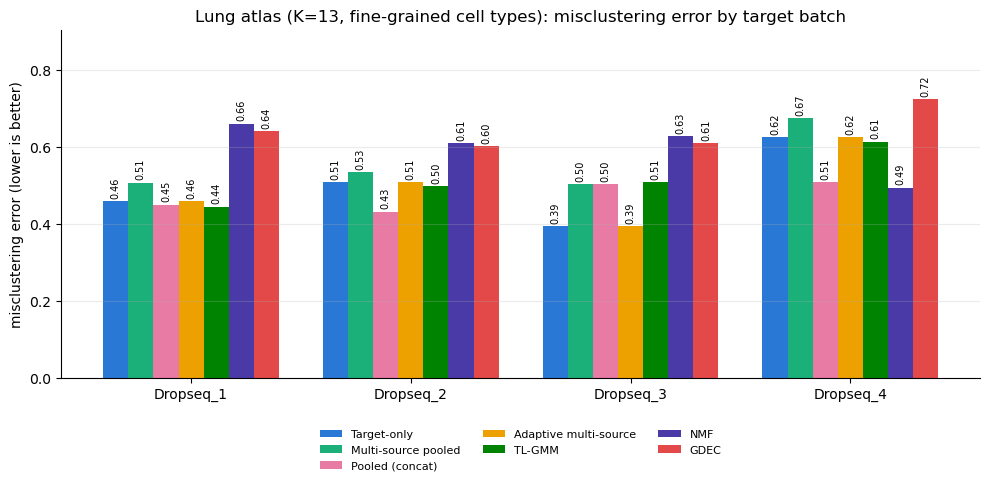

In [5]:
METHOD_COLORS = {
    "target_only": "#2a78d6",
    "multi_source_pooled": "#1baf7a",
    "pooled_concat": "#e87ba4",
    "adaptive_multi_source": "#eda100",
    "tlgmm": "#008300",
    "scrna": "#4a3aa7",
    "gdec_gcnfree": "#e34948",
}
METHOD_ORDER = list(common.METHOD_LABELS.keys())

pivot = results.pivot(index="method", columns="target", values="misclustering").reindex(
    index=METHOD_ORDER, columns=common.BATCHES
)

n_methods = len(METHOD_ORDER)
x = np.arange(len(common.BATCHES))
width = 0.8 / n_methods

fig, ax = plt.subplots(figsize=(10, 5))
for i, method in enumerate(METHOD_ORDER):
    offset = (i - (n_methods - 1) / 2) * width
    vals = pivot.loc[method].values
    bars = ax.bar(x + offset, vals, width, label=common.METHOD_LABELS[method],
                   color=METHOD_COLORS[method])
    ax.bar_label(bars, fmt="%.2f", padding=2, fontsize=7, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(common.BATCHES)
ax.set_ylabel("misclustering error (lower is better)")
ax.set_title("Lung atlas (K=13, fine-grained cell types): misclustering error by target batch")
ax.set_ylim(0, max(pivot.values.max() * 1.25, 0.05))
ax.spines[["top", "right"]].set_visible(False)
ax.grid(True, axis="y", alpha=0.25)
ax.legend(frameon=False, fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
fig.tight_layout()

fig_path = os.path.join(RESULTS_DIR, "lung_atlas_misclustering.pdf")
fig.savefig(fig_path, bbox_inches="tight")
print(f"Wrote {fig_path}")
plt.show()